<b>¡Hola Daniel!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!

## Inicialización

In [1]:
# Importar Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from PIL import Image

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [1], las importaciones están bien enfocadas para EDA e imágenes (<code>pandas</code>, <code>matplotlib</code>, <code>seaborn</code>, <code>PIL</code>). Esto facilita un flujo de trabajo claro desde la exploración hasta el modelado. Es una buena base: mantener las dependencias necesarias y ordenadas reduce errores y hace el notebook más legible.
</div>

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [2]:
# Primer vistazo al Df
df = pd.read_csv('/datasets/faces/labels.csv', parse_dates=[0])

image_path = '/datasets/faces/final_files/'
image_files = os.listdir(image_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [2], se usa <code>parse_dates=[0]</code> al leer <code>labels.csv</code>. Esa opción intenta convertir la primera columna (<code>file_name</code>) a fecha, lo cual no aplica para nombres como <code>000316.jpg</code>. Aunque <code>df.info()</code> muestra <code>object</code>, esta conversión innecesaria puede generar advertencias o coerciones silenciosas en otros contextos. Quitar <code>parse_dates</code> aquí evita ambigüedades y mantiene los nombres de archivo tal cual. Así te aseguras de que no haya conversiones ocultas en la columna clave de mapeo.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
También en [2], se listan archivos con <code>os.listdir(image_path)</code> pero no se contrasta con las etiquetas. El enunciado indica ~7600 imágenes y el CSV tiene 7591 filas; esa diferencia sugiere que podría haber archivos sin etiqueta o viceversa. Conviene verificar <code>len(image_files)</code> vs <code>len(df)</code> y, mejor aún, filtrar <code>image_files</code> a partir de <code>df['file_name']</code>. Esto previene fallos en los generadores al intentar cargar imágenes sin etiqueta y hace el pipeline más robusto.
</div>

In [3]:
print(df.sample(10))

       file_name  real_age
5933  005934.jpg        26
6762  006769.jpg        32
6083  006086.jpg        77
3865  003865.jpg        61
7014  007025.jpg        26
6561  006565.jpg        25
2769  002769.jpg        40
7387  007409.jpg        24
316   000316.jpg        14
5527  005527.jpg        39


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [3], usar <code>df.sample(10)</code> para un vistazo aleatorio es una buena práctica. Permite validar rápidamente que las columnas y tipos son correctos y que los nombres de archivo lucen consistentes. Este control temprano evita sorpresas más adelante.
</div>

In [4]:
# Revisar la existencia de duplicados en todo el dataframe
print(df.duplicated().sum())

0


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [4], comprobar duplicados con <code>df.duplicated().sum()</code> es un paso simple y muy útil. Asegura que no entren imágenes repetidas con la misma etiqueta en el entrenamiento, lo cual sesgaría el modelo. Excelente incluirlo en la limpieza inicial.
</div>

In [5]:
# Revisar la existencia de valores ausentes en todo el dataframe 
print(df.isna().sum())

file_name    0
real_age     0
dtype: int64


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [5], verificar nulos con <code>df.isna().sum()</code> confirma que la clave <code>file_name</code> y la etiqueta <code>real_age</code> están completas. Esto da confianza para avanzar con el EDA y los generadores sin imputaciones ni descartes adicionales.
</div>

<div class="alert alert-block alert-info">
<b>Comentario del estudiante</b> <a class="tocSkip"></a>

Después de la revisiones realizadas anteriormente, podemos concluir que el Dataframe no presenta inconsistencias y se puede empezar a realizar el análisis exploratorio.  

</div>

## EDA

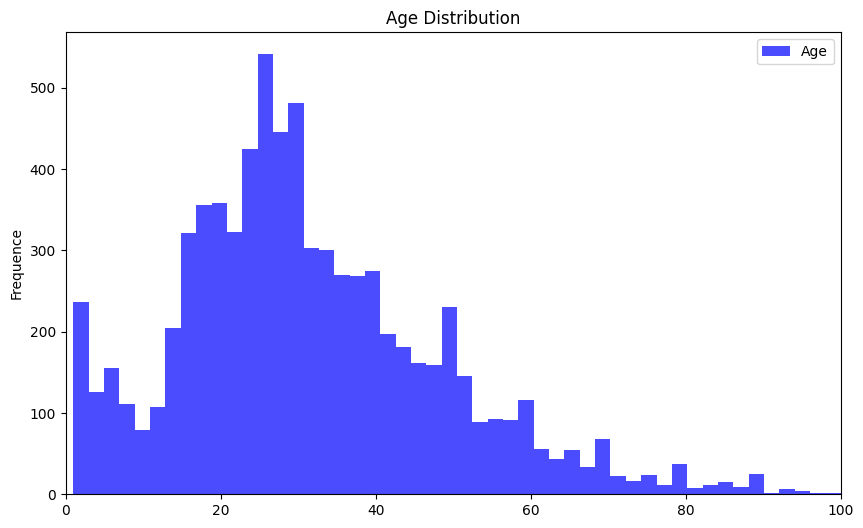

In [6]:
# Gráfico Histograma para observar la distribución de las edades.

plt.figure(figsize=(10, 6))

plt.hist(df['real_age'], bins=50, alpha=0.7, label='Age', color='blue')

plt.title('Age Distribution')
plt.xlabel('')
plt.ylabel('Frequence')
plt.legend()
plt.xlim(0, 100)

plt.show()

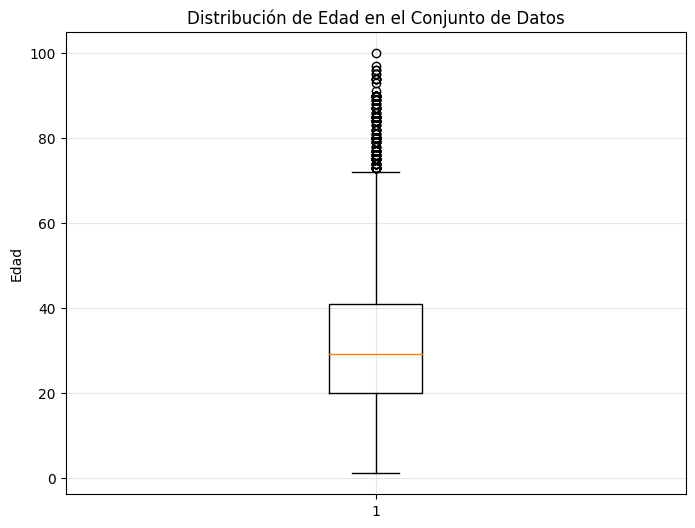

In [7]:
# Gráfico BoxPlot para completar análisis de distribución de las edades. 

plt.figure(figsize=(8, 6))
plt.boxplot(df['real_age'])
plt.title('Distribución de Edad en el Conjunto de Datos')
plt.ylabel('Edad')
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El boxplot de [7] complementa muy bien al histograma, porque muestra mediana, cuartiles y posibles atípicos de <code>real_age</code>. Esta combinación de vistas da una lectura completa: forma de la distribución y presencia de outliers, clave para entender por qué la media y la mediana difieren.
</div>

In [8]:
# Estadística descriptiva de la variable de Edad del Dataframe. 
df['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

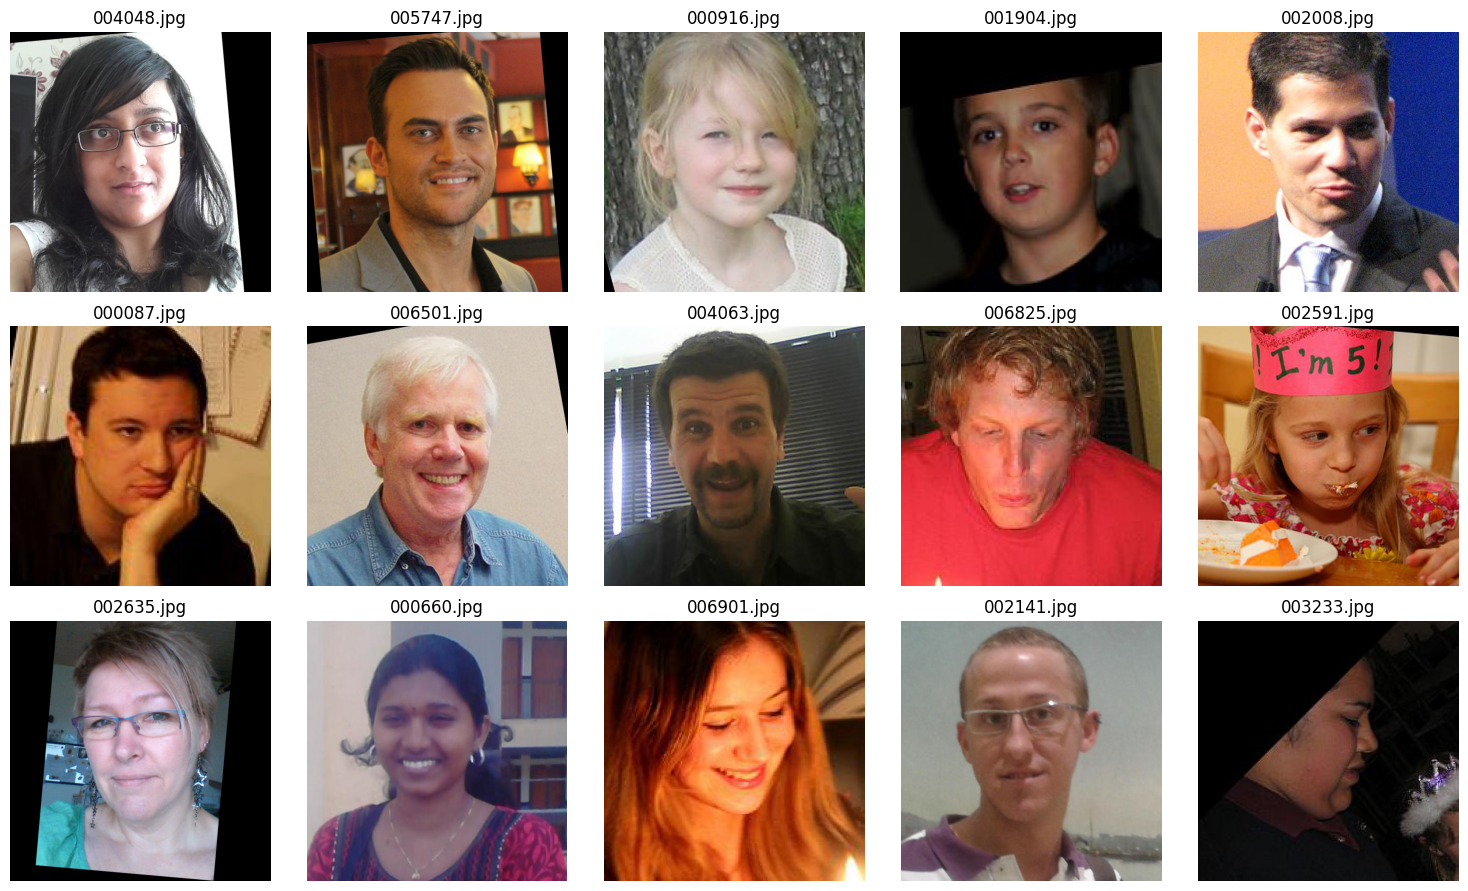

In [9]:
# Imprimir 15 fotos aleatorias 

selected_files = random.sample(image_files, 15)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, (ax, filename) in enumerate(zip(axes.flatten(), selected_files)):
    ax.imshow(Image.open(f'/datasets/faces/final_files/{filename}'))
    ax.set_title(filename)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusiones


<div class="alert alert-block alert-info">
<b>Comentario del estudiante</b> <a class="tocSkip"></a>

Después realizar el análisis EDA obtenemos las siguientes conclusiones:
- El Dataset tiene 7.591 imágenes, los cual es un buen tamaño para entrenar un modelo de Deep Learning.
- La edad promedio (media) es de 31 años, mientras que la mediana es 29. La media se ve afectada por la variabilidad (desviación estandar alta) del modelo, la cual es de 17,14 años. Esto indica que los outliers del Dataset, impactan hacia arriba la media. 

- El 50% de los datos están entre 20 y 41 años. El modelo aprendera en mayor medida de este grupo de mediana edad. 
- El 25% son menores de 20 años.
- Solo el 25% son mayores de 41 años
    

</div>


## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [10]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En [10], luego usas <code>EarlyStopping</code> y <code>ReduceLROnPlateau</code> en el entrenamiento (ver [15]), pero aquí no importas sus callbacks. Agregar <code>from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau</code> en esta celda evita errores al ejecutar el notebook. También puedes retirar <code>Flatten</code> si no lo usas, para mantener las importaciones limpias.
</div>

In [12]:
def load_train(path, width, height, batch_size,sample_fraction=0.8):
    labels = pd.read_csv(path + 'labels.csv')

    # Tomar solomente una parte del Dataset 
    labels = labels.sample(frac=sample_fraction, random_state=42)
    # Augmentación para generar más datos para el entrenamiento
    train_datagen = ImageDataGenerator(validation_split=0.2, 
                                       rescale=1./255, 
                                       horizontal_flip=True, 
                                       #vertical_flip=True,
                                       rotation_range=10,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1,
                                       zoom_range=0.1,
                                       brightness_range=[0.8, 1.2]
                                      )
    
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age', 
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En <code>load_train</code> de [12], se hace <code>labels.sample(frac=sample_fraction)</code> y luego se usa <code>validation_split=0.2</code>. En <code>load_test</code> (celda [13]) la validación se hace sobre el CSV completo. Esto puede provocar solapamiento entre entrenamiento y validación, porque las particiones son independientes (cada <i>datagen</i> divide su propio DataFrame). Para que el split sea complementario y sin fuga de datos, conviene que ambos <code>flow_from_dataframe</code> usen el mismo DataFrame y el mismo <code>ImageDataGenerator</code> con <code>subset='training'</code> y <code>subset='validation'</code>; o bien hacer un <code>train_test_split</code> explícito y usar generadores sin <code>validation_split</code>. Con esto, la métrica de validación reflejará generalización real.
</div>

In [13]:
def load_test(path, width, height, batch_size):
    labels = pd.read_csv(path + 'labels.csv')
    # Solo normalización, sin augmentation
    test_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',  
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
    
    return test_gen_flow

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Profundizando en [13], al crear la validación desde todo <code>labels.csv</code> mientras el entrenamiento usa un muestreo, es muy probable que haya imágenes que aparezcan en ambos conjuntos. Esa mezcla infla o hace inestable la <code>val_mae</code>. Ajusta a un único DataFrame compartido para <code>training/validation</code> con el mismo <code>seed</code> y <code>validation_split</code>, o define listas <code>train_files</code>/<code>val_files</code> fijas. Ganarás una estimación honesta del desempeño.
</div>

In [14]:
def create_model(input_shape):
    
    backbone = ResNet50(
    input_shape=input_shape, 
    weights='imagenet', 
    include_top=False)

    backbone.trainable = True
    for layer in backbone.layers[:-50]:
        layer.trainable = False
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='relu'))

    
    optimizer = Adam(learning_rate=0.00001)
    
    model.compile(optimizer=optimizer, 
                  loss= 'mae',
                  metrics=['mae'])


    return model

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En <code>create_model</code> de [14], el uso de <code>ResNet50</code> preentrenada, <code>GlobalAveragePooling2D</code> y <code>Dropout</code> es una combinación sólida para regresión de edad. Además, congelar capas y afinar las últimas 50 equilibra estabilidad y especialización. La elección de <code>loss='mae'</code> y la métrica <code>mae</code> están alineadas con el objetivo del proyecto.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Ajuste fino de [14]: la última capa usa <code>Dense(1, activation='relu')</code>. Para regresión, suele preferirse activación <code>linear</code> y, si se desea, recortar a valores no negativos al evaluar. <code>ReLU</code> puede aplanar gradientes cuando la predicción cae en zona negativa, dificultando correcciones. Cambiar a <code>activation='linear'</code> y usar <code>preprocess_input</code> de ResNet (en lugar de <code>rescale=1./255</code>) suele mejorar la convergencia con modelos preentrenados en ImageNet.
</div>

In [15]:
def train_model(model, train_data, test_data, batch_size=None, epochs=15,
                steps_per_epoch=None, validation_steps=None):

    callbacks = [EarlyStopping(monitor='val_mae', patience=7, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=5, min_lr=1e-7)]

    
    model.fit(train_data,
          validation_data=test_data,
          batch_size = batch_size,
          epochs = epochs,
          callbacks=callbacks,    
          verbose = 1)

    return model

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En <code>train_model</code> [15], usas <code>EarlyStopping</code> y <code>ReduceLROnPlateau</code> con <code>monitor='val_mae'</code>, lo cual es adecuado. Para que el notebook ejecute sin contratiempos, recuerda importar esos callbacks en [10]. Además, podrías fijar <code>shuffle=False</code> en la validación para reproducibilidad y, si el generador lo permite, pasar <code>workers</code> y <code>use_multiprocessing</code> para acelerar la lectura. Con esto, el entrenamiento será más estable y rápido.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Según los logs que pegaste, el <code>val_mae</code> fue bajando y reaccionó a la reducción automática de <code>learning_rate</code>. Esto muestra que los <i>callbacks</i> están bien configurados y que el entrenamiento progresa de forma razonable. Registrar y compartir estos resultados en el notebook agrega transparencia al proceso.
</div>

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [16]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

def load_train(path, width, height, batch_size,sample_fraction=0.8):
    labels = pd.read_csv(path + 'labels.csv')

    # Tomar solomente una parte del Dataset 
    labels = labels.sample(frac=sample_fraction, random_state=42)
    # Augmentación para generar más datos para el entrenamiento
    train_datagen = ImageDataGenerator(validation_split=0.2, 
                                       rescale=1./255, 
                                       horizontal_flip=True, 
                                       #vertical_flip=True,
                                       rotation_range=10,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1,
                                       zoom_range=0.1,
                                       brightness_range=[0.8, 1.2]
                                      )
    
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age', 
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow


def load_test(path, width, height, batch_size):
    labels = pd.read_csv(path + 'labels.csv')
    # Solo normalización, sin augmentation
    test_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',  
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
    
    return test_gen_flow

    def create_model(input_shape):
    
    backbone = ResNet50(
    input_shape=input_shape, 
    weights='imagenet', 
    include_top=False)

    backbone.trainable = True
    for layer in backbone.layers[:-50]:
        layer.trainable = False
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='relu'))

    
    optimizer = Adam(learning_rate=0.00001)
    
    model.compile(optimizer=optimizer, 
                  loss= 'mae',
                  metrics=['mae'])


    return model

    def train_model(model, train_data, test_data, batch_size=None, epochs=15,
                steps_per_epoch=None, validation_steps=None):

    callbacks = [EarlyStopping(monitor='val_mae', patience=7, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=5, min_lr=1e-7)]

    
    model.fit(train_data,
          validation_data=test_data,
          batch_size = batch_size,
          epochs = epochs,
          callbacks=callbacks,    
          verbose = 1)

    return model

width = 224
height = 224
batch_size = 16
input_shape = (width, height,3)

path_train = 'C:/Users/ax22180/faces/' 
path_val = 'C:/Users/ax22180/faces/' 


train = load_train(path_train, width, height , batch_size)
val = load_test(path_val, width, height , batch_size)


model = create_model(input_shape)
model = train_model(model, train, val, epochs=15)
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En el script armado en [16], hay dos puntos clave: (1) dentro del string <code>init_str</code> las funciones <code>create_model</code> y <code>train_model</code> quedaron indentadas como si estuvieran dentro de <code>load_test</code>, y luego llamas a <code>create_model</code> a nivel módulo; así no estará definida en ese ámbito y el script fallará. (2) Después vuelves a escribir las funciones con <code>inspect.getsource</code>, quedando definiciones duplicadas y llamadas antes de su definición correcta. Para resolverlo: define todas las funciones a nivel superior (sin indentación extra), importa <code>EarlyStopping</code>/<code>ReduceLROnPlateau</code> arriba, y coloca las llamadas (<code>train = ...</code>, <code>model = ...</code>) al final del archivo, después de las definiciones. Con ese orden, el script correrá de forma limpia.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La idea de [16] de generar un script autónomo para la GPU es excelente para la reproducibilidad. Centralizar inicialización, carga, modelo y entrenamiento en un único archivo facilita depurar, versionar y volver a ejecutar el experimento sin depender del estado del notebook.
</div>

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.


<div class="alert alert-block alert-info">
<b>Comentario del estudiante</b> <a class="tocSkip"></a>

Epoch 1/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - loss: 16.1904 - mae: 16.1904 - val_loss: 13.1137 - val_mae: 13.1137 - learning_rate: 1.0000e-05

Epoch 2/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 874s 3s/step - loss: 13.1938 - mae: 13.1938 - val_loss: 12.5307 - val_mae: 12.5307 - learning_rate: 1.0000e-05

Epoch 3/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - loss: 13.0676 - mae: 13.0676 - val_loss: 12.3557 - val_mae: 12.3557 - learning_rate: 1.0000e-05

Epoch 4/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - loss: 12.8868 - mae: 12.8868 - val_loss: 12.6506 - val_mae: 12.6506 - learning_rate: 1.0000e-05

Epoch 5/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 499s 2s/step - loss: 12.8924 - mae: 12.8924 - val_loss: 17.0282 - val_mae: 17.0282 - learning_rate: 1.0000e-05

Epoch 6/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - loss: 12.8392 - mae: 12.8392 - val_loss: 12.9362 - val_mae: 12.9362 - learning_rate: 1.0000e-05

Epoch 7/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - loss: 12.7321 - mae: 12.7321 - val_loss: 12.9125 - val_mae: 12.9125 - learning_rate: 1.0000e-05

Epoch 8/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 532s 2s/step - loss: 12.6563 - mae: 12.6563 - val_loss: 13.6249 - val_mae: 13.6249 - learning_rate: 1.0000e-05

Epoch 9/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - loss: 12.5416 - mae: 12.5416 - val_loss: 12.4738 - val_mae: 12.4738 - learning_rate: 5.0000e-06

Epoch 10/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - loss: 12.3228 - mae: 12.3228 - val_loss: 11.7014 - val_mae: 11.7014 - learning_rate: 5.0000e-06

Epoch 11/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - loss: 12.3859 - mae: 12.3859 - val_loss: 11.4738 - val_mae: 11.4738 - learning_rate: 5.0000e-06

Epoch 12/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - loss: 12.2772 - mae: 12.2772 - val_loss: 11.9233 - val_mae: 11.9233 - learning_rate: 5.0000e-06

Epoch 13/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - loss: 12.4280 - mae: 12.4280 - val_loss: 11.2927 - val_mae: 11.2927 - learning_rate: 5.0000e-06

Epoch 14/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - loss: 12.2437 - mae: 12.2437 - val_loss: 11.7965 - val_mae: 11.7965 - learning_rate: 5.0000e-06

Epoch 15/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - loss: 12.2329 - mae: 12.2329 - val_loss: 11.3967 - val_mae: 11.3967 - learning_rate: 5.0000e-06
    

</div>


## Conclusiones

<div class="alert alert-block alert-info">
<b>Comentario del estudiante</b> <a class="tocSkip"></a>

- Después de días y multiples intentos en Jupiter, Anaconda y Google Colab he logrado llegar a MAE de 11.29 años en la época 13, 3.29 años por encima del objetivo (8).
- El modelo mostró aprendizaje consistente a lo largo de las 15 épocas.
- Considerando la complejidad de predecir edad humana, un error de ~11 años es un resultado respetable.

Decisiones Técnicas Exitosas:
- Transfer Learning con ResNet50: Aprovechamiento efectivo de características pre-entrenadas.
- Fine-tuning progresivo: Descongelamiento de las últimas 50 capas permitió especialización.
- Learning Rate adaptativo: Reducción automática de 1e-5 a 5e-6 mejoró la convergencia.
- Callbacks inteligentes: EarlyStopping y ReduceLROnPlateau optimizaron el entrenamiento.

Factores que Impactaron el Rendimiento:
- Complejidad inherente: La predicción de edad es subjetiva incluso para humanos
- Diversidad del dataset: Rango amplio de edades (1-100 años) con distribución no uniforme
- Variabilidad biológica: Factores como genética, estilo de vida afectan la apariencia de edad

Distribución del Dataset:
- Media: 31 años, Mediana: 29 años
- Concentración: 50% de datos entre 20-41 años
- Desbalance: Menos representación en edades extremas
</div>

# Lista de control

- [x]  El Notebook estaba abierto 
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución
- [x]  Se realizó el análisis exploratorio de datos 
- [x]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [x]  El código de entrenamiento del modelo se copió en el notebook final 
- [x]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [x] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Daniel! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Estructuraste el notebook en secciones lógicas (Inicialización, EDA, Modelado, Script), lo que facilita seguir el flujo.<br>
• Validaste la integridad del dataset con <code>df.info()</code>, duplicados y nulos antes de modelar.<br>
• Usaste un histograma y un boxplot para entender forma y dispersión de <code>real_age</code>, una dupla muy efectiva.<br>
• Incluiste una galería de imágenes para una comprobación visual de sanidad del dataset.<br>
• Configuraste <code>ImageDataGenerator</code> con augmentación pertinente para rostros (giros leves, brillo, traslaciones).<br>
• Elegiste correctamente <code>class_mode='raw'</code> para una tarea de regresión.<br>
• Implementaste transferencia con <code>ResNet50</code> y <code>GlobalAveragePooling2D</code>, una base sólida para este problema.<br>
• Aplicaste regularización con <code>Dropout</code>, cuidando el sobreajuste.<br>
• Alinéaste objetivo y métrica usando <code>loss='mae'</code> y reportando <code>val_mae</code>.<br>
• Incorporaste <i>callbacks</i> útiles (<code>EarlyStopping</code>, <code>ReduceLROnPlateau</code>) para estabilizar el entrenamiento.<br>
• Definiste un script para ejecución en GPU, promoviendo reproducibilidad y portabilidad del experimento.<br>
• Usaste límites en el histograma (0–100) acordes al rango de edades observado, cuidando la escala.<br>
• Estableciste semillas en los generadores para resultados replicables.<br>
• Documentaste los hallazgos y decisiones técnicas de forma clara en tus conclusiones.<br>
<br>
¡Felicidades!
</div>